In [24]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import os

In [25]:
data = pd.read_csv("./dynamic_pricing.csv")
print(data.describe)

<bound method NDFrame.describe of      Number_of_Riders  Number_of_Drivers Location_Category  \
0                  90                 45             Urban   
1                  58                 39          Suburban   
2                  42                 31             Rural   
3                  89                 28             Rural   
4                  78                 22             Rural   
..                ...                ...               ...   
995                33                 23             Urban   
996                84                 29             Urban   
997                44                  6          Suburban   
998                53                 27          Suburban   
999                78                 63             Rural   

    Customer_Loyalty_Status  Number_of_Past_Rides  Average_Ratings  \
0                    Silver                    13             4.47   
1                    Silver                    72             4.06   
2          

### Data analysis

In [26]:
fig = px.scatter(
    data,
    x="Expected_Ride_Duration",
    y="Historical_Cost_of_Ride",
    title="Expected Duration of Ride vs Cost of Ride",
    trendline="ols",
)
fig.show()

In [27]:
fig = px.box(
    data,
    x="Vehicle_Type",
    y="Historical_Cost_of_Ride",
    title="Cost of Ride vs Vehicle type used",
)
fig.show()

In [28]:
corr_matrix = data.select_dtypes(include=["number"]).corr()
fig = go.Figure(
    data=go.Heatmap(z=corr_matrix.values, x=corr_matrix.columns, y=corr_matrix.columns)
)
fig.show()

### Implementation

- High-demand periods and low supply sceneios lead to price increment
- Low demand periods and high supply scenerios lead to price decrement.

In [29]:
# demand
high_demand_percentile = 75
low_demand_percentile = 25
data["demand_multiplier"] = np.where(
    data["Number_of_Riders"]
    > np.percentile(data["Number_of_Riders"], high_demand_percentile),
    data["Number_of_Riders"]
    / np.percentile(data["Number_of_Riders"], high_demand_percentile),
    data["Number_of_Riders"]
    / np.percentile(data["Number_of_Riders"], low_demand_percentile),
)

In [30]:
# supply
high_supply_percentile = 75
low_supply_percentile = 25

data["supply_multiplier"] = np.where(
    data["Number_of_Drivers"]
    > np.percentile(data["Number_of_Drivers"], low_supply_percentile),
    np.percentile(data["Number_of_Drivers"], high_supply_percentile)
    / data["Number_of_Drivers"],
    np.percentile(data["Number_of_Drivers"], low_supply_percentile)
    / data["Number_of_Drivers"],
)

In [31]:
# price
high_demand_thres = 1.2
low_demand_thres = 0.8
high_supply_thres = 0.8
low_supply_thres = 1.2

data["new_cost_ride"] = data["Historical_Cost_of_Ride"] * (
    np.maximum(data["demand_multiplier"], low_demand_thres)
    * np.maximum(data["supply_multiplier"], high_supply_thres)
)

In [32]:
# profit percentage of each ride
data["profit_percentage"] = (
    (data["new_cost_ride"] - data["Historical_Cost_of_Ride"])
    / data["Historical_Cost_of_Ride"]
) * 100

In [33]:
profitable_rides = data[data["profit_percentage"] > 0]
loss_rides = data[data["profit_percentage"] < 0]

In [34]:
profit_rides_cnt = len(profitable_rides)
loss_rides_cnt = len(loss_rides)

In [35]:
labels = ["Profitable Rides", "Loss Rides"]
values = [profit_rides_cnt, loss_rides_cnt]

# Corrected Pie chart syntax
fig = go.Figure(data=go.Pie(labels=labels, values=values, hole=0.4))
fig.update_layout(title="Profitability of Rides (New Pricing vs Historical Pricing)")
fig.show()

In [36]:
fig = px.scatter(
    data,
    x="Expected_Ride_Duration",
    y="new_cost_ride",
    title="Expected Ride Duration vs new Ride Cost",
    trendline="ols",
)
fig.show()

## Training


##### Preprocessing

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
def data_preprocessing_pipeline(data):
    numeric_features = data.select_dtypes(include=["float", "int"]).columns
    categorical_features = data.select_dtypes(include=["object"]).columns

    # Handling the missing values of numeric_features.
    data[numeric_features] = data[numeric_features].fillna(
        data[numeric_features].mean()
    )

    # Handling the outliers
    for feature in numeric_features:
        Q1 = data[feature].quantile(0.25)
        Q3 = data[feature].quantile(0.75)
        IQR = Q3 - Q1  # InterQuartile deviation.
        lower_bound = Q1 - (1.5 * IQR)
        upper_bound = Q3 + (1.5 * IQR)

        data[feature] = np.where(
            (data[feature] < lower_bound) | (data[feature] > upper_bound),
            data[feature].mean(),
            data[feature],
        )

    # Again handle the missing categorical values:
    data[categorical_features] = data[categorical_features].fillna(
        data[categorical_features].mode().iloc[0]
    )
    return data

In [39]:
## Converting the vehicle type to numerical type
data["Vehicle_Type"] = data["Vehicle_Type"].map({"Premium": 1, "Economy": 0})

##### Splitting of data

In [40]:
from sklearn.model_selection import train_test_split

x = np.array(
    data[
        [
            "Number_of_Riders",
            "Number_of_Drivers",
            "Vehicle_Type",
            "Expected_Ride_Duration",
        ]
    ]
)
y = np.array(data["new_cost_ride"])

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
y_train = y_train.ravel()
y_test = y_test.ravel()

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(x_train, y_train)

RandomForestRegressor()

#### Testing


In [41]:
def get_vehicle_type_numeric(vehicle_type):
    vehicle_type_mapping = {"Premium": 1, "Economy": 0}
    vehicle_type_numeric = vehicle_type_mapping.get(vehicle_type)
    return vehicle_type_numeric

In [42]:
def price_predictor(no_of_riders, no_of_drivers, vehicle_type, expected_duration):
    vehicle_type_numeric = get_vehicle_type_numeric(vehicle_type)
    if vehicle_type_numeric is None:
        raise ValueError("Invalid vehicle type")

    input_data = np.array(
        [[no_of_riders, no_of_drivers, vehicle_type_numeric, expected_duration]]
    )
    predicted_price = model.predict(input_data)
    return predicted_price

In [43]:
### Example data set:
no_of_riders = 50
no_of_drivers = 10
vehicle_type = "Premium"
RideDuration = 30
predicted_price = price_predictor(
    no_of_riders, no_of_drivers, vehicle_type, RideDuration
)
print("Predicted Price: ", predicted_price)

Predicted Price:  [305.37182281]


In [48]:
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")

# 2. Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae:.4f}")

# 3. Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.4f}")

R² Score: 0.8636
MAE: 121.1190
RMSE: 176.7413


In [45]:
y_pred = model.predict(x_test)
fig = go.Figure()

fig.add_trace(
    go.Scatter(x=y_test.flatten(), y=y_pred, mode="markers", name="Actual vs Predicted")
)

fig.add_trace(
    go.Scatter(
        x=[min(y_test.flatten()), max(y_test.flatten())],
        y=[min(y_test.flatten()), max(y_test.flatten())],
        mode="lines",
        name="Ideal",
        line=dict(color="red", dash="dash"),
    )
)

fig.update_layout(
    title="Actual vs Predicted Values",
    xaxis_title="Actual Values",
    yaxis_title="Predicted Values",
    showlegend=True,
)

fig.show()

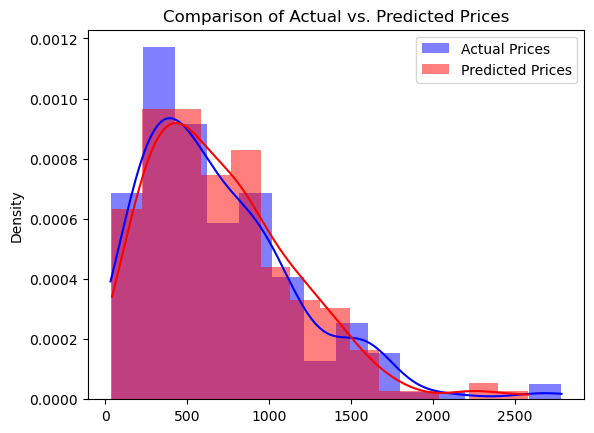

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: y_true (actual prices) and y_pred (predicted prices)
y_pred = model.predict(x_test)
sns.histplot(
    y_test, color="blue", label="Actual Prices", kde=True, stat="density", linewidth=0
)
sns.histplot(
    y_pred, color="red", label="Predicted Prices", kde=True, stat="density", linewidth=0
)
plt.legend()
plt.title("Comparison of Actual vs. Predicted Prices")
plt.show()